In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

words = open("../names.txt", "r").read().splitlines()

In [24]:
# 1. create table to map from char to index
chars = sorted(list(set("".join(words))))
stoi = {char: i+1 for i, char in enumerate(chars)}
stoi['.'] = 0
itos = {i: s for s, i in stoi.items()}
vacab_size = len(itos)
print(f"vocabulary size: {vacab_size} sample size {len(words)}")

vocabulary size: 27 sample size 32033


In [50]:
# 2. build data set with specific context window
def build_dataset(words, block_size=3):
    X = []
    Y = []
    for word in words: 
        context = [0] * block_size
        for ch in word + '.':
            index = stoi[ch]
            X.append(context)
            Y.append(index)
            context = context[1:] + [index]
    return torch.tensor(X), torch.tensor(Y)

# Set up training/val/test data sets
# 80% training, 10% eval, 10% test
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))
block_size = 8
g = torch.Generator().manual_seed(42)

Xtr, Ytr = build_dataset(words[: n1], block_size)
Xdev, Ydev = build_dataset(words[n1: n2], block_size)
Xtest, Ytest = build_dataset(words[n2:], block_size)

print(f"Xtr shape {Xtr.shape} Ytr shape {Ytr.shape}")

Xtr shape torch.Size([182778, 8]) Ytr shape torch.Size([182778])


In [71]:
from typing import Any

class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        # Xvaier initialize weights
        self.weight = torch.randn((fan_in, fan_out), generator=g) / (fan_in ** 0.5)
        # Initialize bias as zeroes if bias is true
        self.bias = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

In [72]:
class BatchNorm1d:
    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #parameters
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #running mean and var
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x: torch.Tensor):
        #compute batch norm in training mode
        if self.training:
            dim = 0 if x.ndim == 2 else (0, 1)
            mean = x.mean(dim=dim, keepdim=True)
            var = x.var(dim=dim, keepdim=True, unbiased=False)
        else:
            mean = self.running_mean
            var = self.running_var
        x_norm = (x - mean) / torch.sqrt(var + self.eps)
        self.out = self.gamma * x_norm + self.beta
        # Update running mean and bar
        if self.training:
            with torch.no_grad():
                # .squeeze() to remove all the 1 dims in mean，to keep running_mean as 1D Tensor (dim,)
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * mean.squeeze()
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * var.squeeze()
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [73]:
from typing import Any

class Embedding:
    def __init__(self, num_embeds, embed_dim):
        self.weight = torch.randn((num_embeds, embed_dim))

    def __call__(self, x):
        self.out = self.weight[x]
        return self.out

    def parameters(self):
        return [self.weight]

class Flatten:
    def __call__(self, x: torch.Tensor):
        self.out = x.view(x.shape[0], -1)
        return self.out

    def parameters(self):
        return []

class FlattenConsecutive:
    def __init__(self, n):
        self.n = n

    def __call__(self, x) -> Any:
        B, T, C = x.shape
        x = x.view(B, T // self.n, C * self.n)
        if x.shape[1] == 1:
            x = x.squeeze(1)
        self.out = x
        return self.out

    def parameters(self):
        return []

class Sequential:
    def __init__(self, layers):
        self.layers = layers

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        self.out = x
        return self.out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

    def train(self):
        for layer in self.layers:
            layer.training = True

    def eval(self):
        for layer in self.layers:
            layer.training = False

    

In [74]:
emb_size = 24
hidden_dim = 128
out_dim = vacab_size

# 6 layers MLP
model = Sequential([ 
    # construct embeddings
    Embedding(vacab_size, emb_size),
    # input layer 1
    # input dim (B, block_size, emb_size), output dim (B, block_size / 2, hidden_dim)
    FlattenConsecutive(2),
    Linear(emb_size * 2, hidden_dim, bias=False), 
    BatchNorm1d(hidden_dim),
    Tanh(),
    # input layer 2
    # input dim (B, block_size / 2, hidden_dim), output dim (B, block_size / 4, hidden_dim)
    FlattenConsecutive(2),
    Linear(hidden_dim * 2, hidden_dim, bias=False), 
    BatchNorm1d(hidden_dim),
    Tanh(),
    # input layer 3
    # input dim (B, block_size / 4, hidden_dim), output dim (B, hidden_dim)
    FlattenConsecutive(2),
    Linear(hidden_dim * 2, hidden_dim, bias=False), 
    BatchNorm1d(hidden_dim),
    Tanh(),
    # output layer, no tanh
    Linear(hidden_dim, out_dim),
])

# Adjust initialized parameters
with torch.no_grad():
    # output layer: make less confident to avoid initial loss too large
    model.layers[-1].weight *= 0.1
    # apply tanh gain to weights of all other layers
    for layer in model.layers[: -1]:
        if isinstance(layer, Linear):
            layer.weight *= 5/3

for p in model.parameters():
    p.requires_grad = True
print(f"Total params: {sum(p.nelement() for p in model.parameters())}") # number of parameters in total

Total params: 76579


In [75]:
# Verify the shape is correct
x_batch = Xtr[:4]
print(f"Input: {x_batch.shape}")
s = x_batch
for layer in model.layers:
    s = layer(s)
    print(f"{layer.__class__.__name__:20s} -> {tuple(s.shape)}")

Input: torch.Size([4, 8])
Embedding            -> (4, 8, 24)
FlattenConsecutive   -> (4, 4, 48)
Linear               -> (4, 4, 128)
BatchNorm1d          -> (4, 4, 128)
Tanh                 -> (4, 4, 128)
FlattenConsecutive   -> (4, 2, 256)
Linear               -> (4, 2, 128)
BatchNorm1d          -> (4, 2, 128)
Tanh                 -> (4, 2, 128)
FlattenConsecutive   -> (4, 256)
Linear               -> (4, 128)
BatchNorm1d          -> (4, 128)
Tanh                 -> (4, 128)
Linear               -> (4, 27)


In [ ]:
batch_size = 64
max_steps = 200000

ud = [] # update to date ratio change history
lossi = [] #log loss change history

model.train()

for step in range(max_steps):
    # 1. select a random mini-batch from training data set
    batch_idxes = torch.randint(0, Xtr.shape[0], (batch_size,))

    # 2. prepare training data
    # x: (batch_size, block_size)
    # y: (batch_size,)
    x = Xtr[batch_idxes]
    y = Ytr[batch_idxes]

    # 3. forward pass
    logits = model(x)
    loss = F.cross_entropy(logits, y)

    # 4. backward pass
    for layer in model.layers:
        layer.out.retain_grad() #Retain grad for non-leaf node, debug only
    for p in model.parameters():
        p.grad = None
    loss.backward()

    # 5. optimize with learning rate decay
    lr = 0.1 if step < 150000 else 0.01
    for p in model.parameters():
        p.data -= lr * p.grad

    # track stats
    if step % 10000 == 0: # print every once in a while
        print(f'{step:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

    with torch.no_grad():
        ud.append( [((lr*p.grad).std() / p.data.std()).log10().item() for p in model.parameters()])

    #if step >= 1000:
        #break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.3085


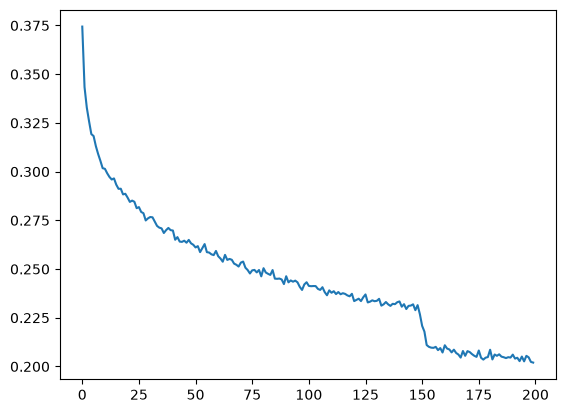

In [69]:
plt.plot(torch.tensor(lossi).view(-1, 1000).mean(1))

In [70]:
model.eval()

@torch.no_grad()
def evaluate_loss(X, Y):
    logits = model(X)
    return F.cross_entropy(logits, Y).item()

print(f"Dev Loss: {evaluate_loss(Xdev, Ydev):.4f}")
print(f"Test Loss: {evaluate_loss(Xtest, Ytest):.4f}")

Dev Loss: 2.3463
Test Loss: 2.4051


In [58]:
# sample from the model
for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      logits = model(torch.tensor([context]))
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

kaylanny.
juliett.
nuva.
joore.
caseen.
jaysie.
oriya.
bridaleya.
sunsere.
aaruse.
evet.
rusrious.
carsten.
kennika.
juleyca.
cioreece.
britton.
sumayroh.
corynne.
daysie.
